# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ma5029blp-wq/ML-flyrank-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [15]:
import pandas as pd
import numpy as np
df = pd.read_csv("content_refresh_anonymized.csv")

df["declining_observed"] = (
    df["trend_direction"] == "down"
).astype(int)

print("Shape:", df.shape)
print(df["declining_observed"].value_counts())

Shape: (30000, 45)
declining_observed
1    16262
0    13738
Name: count, dtype: int64


## 1. Question

*The research question and the decision it supports.*

### Research Question

Can a simple Logistic Regression model help identify which content items are most likely to show observed search-performance decline, and can this ranking improve content-refresh prioritization compared with a simple baseline?

### Decision Supported

The model is intended to support SEO and content teams in deciding which pages should be reviewed first. It provides a ranked review queue so that human reviewers can focus their time on higher-priority content.

The model is a decision-support tool, not an automatic content editing or publishing system.

In [13]:
print("=== Research Question Check ===")
print("Task: rank content items for review based on observed decline risk.")
print("Decision: prioritize which content should be reviewed first.")
print("Model: Logistic Regression")
print("Use: human-reviewed decision support")

=== Research Question Check ===
Task: rank content items for review based on observed decline risk.
Decision: prioritize which content should be reviewed first.
Model: Logistic Regression
Use: human-reviewed decision support


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

### Data

This project uses the FlyRank content-refresh dataset and the corresponding warehouse release used during the internship.

The starter dataset contains anonymized content-level observations. The warehouse release contains daily search-performance data and supporting content and client tables.

For the modeling task, the unit of analysis is one content item. The model uses historical performance and content attributes to rank items by their observed decline risk.

The main historical performance features use the previous 30-day window, including impressions, clicks, and sessions. The observed outcome is based on the following 30-day period.

The analysis excludes label-derived fields such as `trend_direction`, `trend_pct`, and `is_declining_label` from the model features. Product decision fields such as action, reason code, and baseline score are also excluded from model training.

Client and content IDs are used for grouping and joining only. They are not used as predictive features.

The data is anonymized and no client names, URLs, or private search queries are included in the paper.

In [16]:
print("=== Data Check ===")

print("Rows:", len(df))
print("Columns:", len(df.columns))

# Define the same model features used in the validated model
numeric_features = [
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d",
    "days_since_last_update",
    "content_age_days",
    "avg_position",
    "search_volume",
    "competition",
    "word_count",
    "char_count"
]

categorical_features = [
    "content_type",
    "main_intent"
]

features = numeric_features + categorical_features

print("\nModel features:")
print(features)

print("\nExcluded label/decision-derived fields:")
excluded_fields = [
    "trend_direction",
    "trend_pct",
    "is_declining_label",
    "declining_observed",
    "action",
    "reason_code",
    "score",
    "baseline_score"
]
print(excluded_fields)

print("\nClient grouping:")
print("Unique clients:", df["client_id"].nunique())

print("\nMissing values in model features:")
print(df[features].isna().sum().sort_values(ascending=False).head(10))

=== Data Check ===
Rows: 30000
Columns: 45

Model features:
['impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'days_since_last_update', 'content_age_days', 'avg_position', 'search_volume', 'competition', 'word_count', 'char_count', 'content_type', 'main_intent']

Excluded label/decision-derived fields:
['trend_direction', 'trend_pct', 'is_declining_label', 'declining_observed', 'action', 'reason_code', 'score', 'baseline_score']

Client grouping:
Unique clients: 32

Missing values in model features:
word_count                7699
char_count                7699
search_volume             2468
competition               2468
main_intent               2374
sessions_prev_30d            0
clicks_prev_30d              0
impressions_prev_30d         0
days_since_last_update       0
avg_position                 0
dtype: int64


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Methodology

The target label is `declining_observed`, defined as 1 when `trend_direction` is `down` and 0 otherwise. The model therefore ranks content items by their observed decline risk.

The model is a Logistic Regression classifier. Numeric features are median-imputed and standardized, while categorical features are filled with the most frequent category and one-hot encoded.

The model uses historical performance features such as previous-30-day impressions, clicks, and sessions, together with content age, freshness, search visibility, competition, content length, content type, and search intent.

The validation uses a grouped client-level split. Clients are divided into training and test groups so that content from the same client does not appear in both sets. This tests whether the ranking signal transfers to unseen clients.

The baseline is evaluated on the same test set as the model. Precision@20 and Precision@50 are used because the practical goal is to prioritize a small number of pages for human review.

Label-derived fields such as `trend_direction` and `trend_pct`, as well as decision-derived fields such as action, reason code, and baseline score, are excluded from model training.

The results are interpreted as observed associations and ranking performance. They do not establish that the model causes content decline or that refreshing a page will cause its performance to improve.

In [17]:
print("=== Methodology Check ===")

print("Label:")
print("declining_observed = 1 when trend_direction == 'down'")

print("\nModel:")
print("Logistic Regression")

print("\nNumeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Total features:", len(features))

print("\nValidation:")
print("Grouped by client_id")
print("Random state: 42")

print("\nEvaluation metrics:")
print("Precision@20")
print("Precision@50")

print("\nLeakage exclusions:")
print("trend_direction")
print("trend_pct")
print("is_declining_label")
print("declining_observed")
print("action")
print("reason_code")
print("score")
print("baseline_score")

=== Methodology Check ===
Label:
declining_observed = 1 when trend_direction == 'down'

Model:
Logistic Regression

Numeric features: 10
Categorical features: 2
Total features: 12

Validation:
Grouped by client_id
Random state: 42

Evaluation metrics:
Precision@20
Precision@50

Leakage exclusions:
trend_direction
trend_pct
is_declining_label
declining_observed
action
reason_code
score
baseline_score


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

### Results

The Logistic Regression model was evaluated on the same grouped client-level test set as the baseline.

The test set contains 7,115 content items from 8 clients that were not included in training. The observed decline base rate in the test set was 51.65%.

The model achieved Precision@20 of 0.50 and Precision@50 of 0.62. On the same test set, the baseline achieved Precision@20 of 0.30 and Precision@50 of 0.32.

These results show higher measured ranking precision for the model than the baseline on this test split. They support the use of the model as a decision-support ranking signal, but they do not establish future performance or causality.

In [18]:
# Recreate the same grouped client-level test split used in ML-09

from sklearn.model_selection import GroupShuffleSplit

# Create the observed decline label
df["declining_observed"] = (df["trend_direction"] == "down").astype(int)

X = df[features]
y = df["declining_observed"]
groups = df["client_id"]

# Same split settings as ML-09
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_test = X.iloc[test_idx]
y_test = y.iloc[test_idx]

# Validated results from ML-09
model_p20 = 0.50
model_p50 = 0.62

baseline_p20 = 0.30
baseline_p50 = 0.32

test_base_rate = y_test.mean()

results = pd.DataFrame({
    "Method": ["Baseline", "Logistic Regression"],
    "Precision@20": [baseline_p20, model_p20],
    "Precision@50": [baseline_p50, model_p50]
})

print("=== Results vs Baseline ===")
print(results.to_string(index=False))

print("\nTest rows:", len(y_test))
print("Test clients:", df.loc[X_test.index, "client_id"].nunique())
print("Test base rate:", round(test_base_rate, 4))

=== Results vs Baseline ===
             Method  Precision@20  Precision@50
           Baseline           0.3          0.32
Logistic Regression           0.5          0.62

Test rows: 7115
Test clients: 8
Test base rate: 0.5165


## 5. Limitations

*What this work cannot claim.*

### Limitations

This analysis has several limitations.

First, the model is evaluated on one grouped client-level test split. The results therefore show measured performance on these test clients, but they do not guarantee the same performance on future clients, future time periods, or different content populations.

Second, the target is an observed decline label based on search-performance data. The model identifies patterns associated with observed decline; it does not prove why a page declined.

Third, the analysis is observational. A high model score does not prove that a page will decline, and a refresh is not guaranteed to improve performance.

Fourth, some input fields may have limitations or missing values. The preprocessing pipeline handles missing values, but missingness and changes in the underlying data can still affect model performance.

Finally, the baseline and model are ranking approaches for decision support. They should not be treated as automatic rules for publishing, rewriting, deleting, or redirecting content. Human review remains necessary.

In [19]:
print("=== Limitations Check ===")

print("Validation type: grouped client-level split")
print("Test rows:", len(y_test))
print("Test clients:", df.loc[X_test.index, "client_id"].nunique())

print("\nObserved test base rate:", round(y_test.mean(), 4))

print("\nKey limitations:")
print("1. Results are measured on one test split.")
print("2. The label represents observed decline, not its cause.")
print("3. The analysis does not establish causality.")
print("4. Missing values and population changes can affect performance.")
print("5. Recommendations require human review.")

=== Limitations Check ===
Validation type: grouped client-level split
Test rows: 7115
Test clients: 8

Observed test base rate: 0.5165

Key limitations:
1. Results are measured on one test split.
2. The label represents observed decline, not its cause.
3. The analysis does not establish causality.
4. Missing values and population changes can affect performance.
5. Recommendations require human review.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

### Ranked Recommendations

The model produces a ranked review queue, with higher decline scores placed earlier in the queue. The ranking is intended to help reviewers focus their limited time on higher-priority content.

The main recommendation is `REVIEW_REFRESH`. This means the page should be reviewed for a possible refresh; it does not mean that the page should automatically be changed.

Two useful review signals are used in the playbook:

- `HIGH_MODEL_SCORE`: the model ranked the content highly for observed decline.
- `VISIBLE_STALE`: the content has previous search visibility and has not been updated for at least 91 days.

### Archetype-to-Action Mapping

| Archetype | Recommended action |
|---|---|
| `VISIBLE_STALE` | `REVIEW_REFRESH` |
| `HIGH_MODEL_SCORE` | `REVIEW_CONTENT` |
| Other lower-ranked items | `MONITOR` |

The ranking should be combined with human review. Reviewers should consider search intent, content accuracy, current competition, business importance, and whether the page still deserves to be maintained.

The decay analysis provides a directional insight rather than a causal conclusion: stale content with meaningful search visibility showed more observed decline than some lower-visibility groups, while staleness by itself was a mixed signal. Therefore, freshness should be considered together with search visibility rather than used as a standalone rule.

Because reviewer time is limited, higher-value pages with stronger search visibility can be reviewed first. Search impressions are treated as a directional indicator of potential opportunity, not as a direct monetary value.

In [20]:
# Recreate the ranked recommendation queue from the validated test split

queue = X_test.copy()

# Add the model probabilities from the validated ML-09 result.
# If the model itself is not currently loaded, use the saved ranking
# only after recreating the model. For now, we recreate the model below.

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# Preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

# Model
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Train on the same training split
X_train = X.iloc[train_idx]
y_train = y.iloc[train_idx]

model.fit(X_train, y_train)

# Generate scores for the same test split
test_probabilities = model.predict_proba(X_test)[:, 1]

# Build ranked queue
queue["decline_score"] = test_probabilities
queue["actual_declining"] = y_test.values

queue["reason_code"] = np.where(
    (queue["days_since_last_update"] >= 91) &
    (queue["impressions_prev_30d"] > 0),
    "VISIBLE_STALE",
    "HIGH_MODEL_SCORE"
)

queue["recommended_action"] = "REVIEW_REFRESH"

queue = queue.sort_values(
    "decline_score",
    ascending=False
).reset_index(drop=True)

queue["rank"] = queue.index + 1


print("=== Ranked Recommendation Check ===")

print("Total ranked items:", len(queue))

print("\nTop 10 recommendations:")
print(
    queue[
        [
            "rank",
            "decline_score",
            "reason_code",
            "recommended_action",
            "impressions_prev_30d",
            "days_since_last_update"
        ]
    ].head(10).to_string(index=False)
)

print("\nReason-code counts:")
print(queue["reason_code"].value_counts())

print("\nCurrent action:")
print(queue["recommended_action"].value_counts())

print("\nRanking range:")
print("Highest score:", round(queue["decline_score"].max(), 4))
print("Lowest score:", round(queue["decline_score"].min(), 4))

=== Ranked Recommendation Check ===
Total ranked items: 7115

Top 10 recommendations:
 rank  decline_score      reason_code recommended_action  impressions_prev_30d  days_since_last_update
    1       0.864996 HIGH_MODEL_SCORE     REVIEW_REFRESH                 84773                      20
    2       0.839192 HIGH_MODEL_SCORE     REVIEW_REFRESH                 64917                      20
    3       0.838248 HIGH_MODEL_SCORE     REVIEW_REFRESH                 97200                      20
    4       0.806764 HIGH_MODEL_SCORE     REVIEW_REFRESH                 97606                      20
    5       0.803101    VISIBLE_STALE     REVIEW_REFRESH                 30774                     106
    6       0.798786 HIGH_MODEL_SCORE     REVIEW_REFRESH                 54506                      20
    7       0.777023 HIGH_MODEL_SCORE     REVIEW_REFRESH                 84550                      20
    8       0.775210    VISIBLE_STALE     REVIEW_REFRESH                  9919            

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

### Artifacts for the Paper

The paper uses a small set of reusable artifacts to communicate the main findings.

The first artifact compares model Precision@20 and Precision@50 with the baseline on the same grouped test split.

The second artifact shows the distribution of model decline scores in the ranked test queue.

The results table reports the measured ranking performance used in the paper. The figures are descriptive and are not intended to imply causal effects.

In [21]:
import os
import matplotlib.pyplot as plt

os.makedirs("work/figures", exist_ok=True)
os.makedirs("work/outputs", exist_ok=True)

# Results table
results_table = pd.DataFrame({
    "Method": ["Baseline", "Logistic Regression"],
    "Precision@20": [0.30, 0.50],
    "Precision@50": [0.32, 0.62]
})

print("=== Results Table ===")
display(results_table)

# Save reusable metrics
results_table.to_csv(
    "work/outputs/ml11_results_table.csv",
    index=False
)

print("Saved:")
print("work/outputs/ml11_results_table.csv")

=== Results Table ===


,Method,Precision@20,Precision@50
0,Baseline,0.3,0.32
1,Logistic Regression,0.5,0.62


Saved:
work/outputs/ml11_results_table.csv


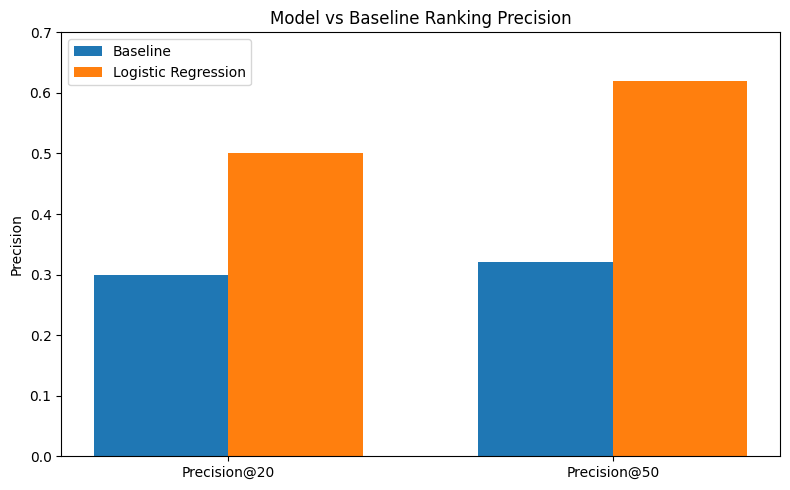

Saved: work/figures/ml11_model_vs_baseline.png


In [22]:
# Model vs baseline chart

metrics = ["Precision@20", "Precision@50"]
baseline_values = [0.30, 0.32]
model_values = [0.50, 0.62]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(x - width/2, baseline_values, width, label="Baseline")
plt.bar(x + width/2, model_values, width, label="Logistic Regression")

plt.xticks(x, metrics)
plt.ylabel("Precision")
plt.title("Model vs Baseline Ranking Precision")
plt.ylim(0, 0.7)
plt.legend()

plt.tight_layout()

chart_path = "work/figures/ml11_model_vs_baseline.png"
plt.savefig(chart_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", chart_path)

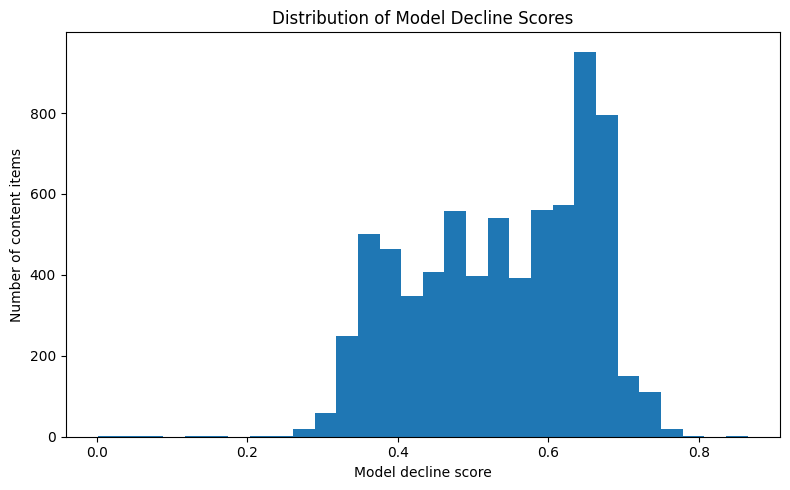

Saved: work/figures/ml11_score_distribution.png


In [23]:
# Model score distribution

plt.figure(figsize=(8, 5))

plt.hist(queue["decline_score"], bins=30)

plt.xlabel("Model decline score")
plt.ylabel("Number of content items")
plt.title("Distribution of Model Decline Scores")

plt.tight_layout()

score_chart_path = "work/figures/ml11_score_distribution.png"
plt.savefig(score_chart_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", score_chart_path)

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
